# Brain MRI Tissue Segmentation — Multi-Class Semantic Segmentation
## SegNet | 4-Class (Background / CSF / Grey Matter / White Matter) | MRBrainS18 Dataset

**Dataset:** MRBrainS18 Challenge Dataset — 7 labeled training subjects, multi-sequence MRI (T1, FLAIR, IR). Only the `training` split is used since the `test` split has no publicly released segmentation labels.

**Label Remapping:** MRBrainS18 uses 9 classes which are consolidated into 4 tissue classes:
- 0 → Background
- 1, 2, 8 → Grey Matter (cortical GM + basal ganglia + brainstem/cerebellum)
- 3, 4 → White Matter (WM + WM lesions)
- 5, 6, 7 → CSF (ventricular CSF + vessels + external CSF)

**Training Notes:**
- Only 7 labeled subjects are available; therefore, every slice (`step=1`) is used to maximize the training dataset.
- Strong data augmentation is applied to improve generalization.
- EarlyStopping is disabled so the model trains for the full configured number of epochs.

## 1. Import Libraries

In [ ]:
import os
import cv2
import random
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import warnings
import tensorflow as tf
tf.config.optimizer.set_jit(False)
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input, Conv2D, UpSampling2D, concatenate,
    BatchNormalization, Dropout, Activation
)
from tensorflow.keras.models import Model
from tensorflow.keras.applications import VGG16
from tensorflow.keras.layers import Layer
from tensorflow.keras import callbacks
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import time
import datetime

!pip install nibabel -q
import nibabel as nib

print('TensorFlow version:', tf.__version__)
print('GPUs available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Configuration

In [ ]:
# ─── Paths ────────────────────────────────────────────────────────────────────
TRAIN_ROOT = '/kaggle/input/datasets/mahi789/trainingg/training'
# Note: test split excluded — no public segmentation labels available

PROCESSED_DIR  = 'mrbrains_processed'
IMAGE_FOLDER   = os.path.join(PROCESSED_DIR, 'images')
MASK_FOLDER    = os.path.join(PROCESSED_DIR, 'masks')
TRAIN_IMG_DIR  = os.path.join(PROCESSED_DIR, 'train', 'images')
TRAIN_MASK_DIR = os.path.join(PROCESSED_DIR, 'train', 'masks')
TEST_IMG_DIR   = os.path.join(PROCESSED_DIR, 'test',  'images')
TEST_MASK_DIR  = os.path.join(PROCESSED_DIR, 'test',  'masks')

# ─── Hyperparameters ──────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 8    # smaller batch — fewer total slices than OASIS/IBSR
EPOCHS      = 100
SEED        = 42
TEST_SPLIT  = 0.20  # slightly larger test split given small dataset
NUM_CLASSES = 4
CLASS_NAMES = ['Background', 'CSF', 'Grey Matter', 'White Matter']

# ─── MRBrainS18 label remapping ───────────────────────────────────────────────
# Original 9 classes → 4 standard tissue classes (matches OASIS-1 and IBSR)
MRBRAINS_REMAP = {
    0: 0,  # Background
    1: 2,  # Cortical Grey Matter → GM
    2: 2,  # Basal Ganglia → GM
    3: 3,  # White Matter → WM
    4: 3,  # White Matter Lesions → WM
    5: 1,  # Ventricular CSF → CSF
    6: 1,  # Vessels/Choroid Plexus → CSF
    7: 1,  # External CSF/Sulci → CSF
    8: 2,  # Brainstem + Cerebellum → GM
}

print('Config set ✓')
print('Label remapping:', MRBRAINS_REMAP)

Config set ✓
Label remapping: {0: 0, 1: 2, 2: 2, 3: 3, 4: 3, 5: 1, 6: 1, 7: 1, 8: 2}


## 3. Extract 2D Slices — Remap 9 Classes to 4

In [ ]:
for d in [IMAGE_FOLDER, MASK_FOLDER,
          TRAIN_IMG_DIR, TRAIN_MASK_DIR,
          TEST_IMG_DIR,  TEST_MASK_DIR]:
    os.makedirs(d, exist_ok=True)

print('Directories ready ✓')

Directories ready ✓


In [ ]:
import os
import shutil
import cv2
import nibabel as nib
import numpy as np
from tqdm import tqdm


def normalize_slice(arr):
    mn, mx = arr.min(), arr.max()
    if mx - mn == 0:
        return np.zeros_like(arr, dtype=np.uint8)
    return ((arr - mn) / (mx - mn) * 255).astype(np.uint8)


def remap_labels(seg_arr, remap_dict):
    """Remap integer label array using a dictionary mapping."""
    out = np.zeros_like(seg_arr, dtype=np.uint8)
    for orig_label, new_label in remap_dict.items():
        out[seg_arr == orig_label] = new_label
    return out


def extract_slices_mrbrains(subject_dir, subject_name, img_out, mask_out, step=1):
    """
    Extract aligned T1 and segmentation slices from MRBrainS18.

    Uses reg_T1.nii because it is already registered to segm.nii.
    Both volumes have shape (240, 240, 48).
    """

    # Candidate paths for registered T1
    t1_candidates = [
        os.path.join(subject_dir, "orig", "reg_T1.nii"),
        os.path.join(subject_dir, "orig", "reg_T1.nii.gz"),
        os.path.join(subject_dir, "pre", "reg_T1.nii"),
        os.path.join(subject_dir, "pre", "reg_T1.nii.gz"),
    ]

    t1_path = None
    for p in t1_candidates:
        if os.path.exists(p):
            t1_path = p
            break

    # Segmentation
    seg_candidates = [
        os.path.join(subject_dir, "segm.nii"),
        os.path.join(subject_dir, "segm.nii.gz"),
    ]

    seg_path = None
    for p in seg_candidates:
        if os.path.exists(p):
            seg_path = p
            break

    if t1_path is None or seg_path is None:
        print(f"Skipping {subject_name} (missing reg_T1 or segm)")
        return 0

    # Load volumes
    brain_vol = np.squeeze(nib.load(t1_path).get_fdata())
    seg_vol = np.squeeze(nib.load(seg_path).get_fdata())

    print(f"{subject_name}")
    print(f"  T1 : {brain_vol.shape}")
    print(f"  Seg: {seg_vol.shape}")

    # Safety check
    if brain_vol.shape != seg_vol.shape:
        print(f"Shape mismatch in {subject_name}, skipping.")
        return 0

    saved = 0

    for i in range(0, brain_vol.shape[2], step):

        brain_slice = brain_vol[:, :, i]
        seg_slice = seg_vol[:, :, i]

        # Skip completely empty MRI slices
        if np.max(brain_slice) == 0:
            continue

        img_arr = normalize_slice(brain_slice)

        mask_arr = remap_labels(
            np.round(seg_slice).astype(np.uint8),
            MRBRAINS_REMAP
        )

        filename = f"{subject_name}_sl{i:03d}.png"

        cv2.imwrite(
            os.path.join(img_out, filename),
            img_arr
        )

        cv2.imwrite(
            os.path.join(mask_out, filename),
            mask_arr
        )

        saved += 1

    return saved


# ---------------------------------------------------------
# Remove previous extracted dataset
# ---------------------------------------------------------

for folder in [IMAGE_FOLDER, MASK_FOLDER]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder, exist_ok=True)


# ---------------------------------------------------------
# Extract slices from all training subjects
# ---------------------------------------------------------

subject_folders = sorted([
    d for d in os.listdir(TRAIN_ROOT)
    if os.path.isdir(os.path.join(TRAIN_ROOT, d))
])

print(f"Found {len(subject_folders)} training subjects:")
print(subject_folders)
print()

total_slices = 0

for subj_name in tqdm(subject_folders, desc="Extracting slices"):

    subj_dir = os.path.join(TRAIN_ROOT, subj_name)

    total_slices += extract_slices_mrbrains(
        subj_dir,
        subj_name,
        IMAGE_FOLDER,
        MASK_FOLDER,
        step=1
    )

print("\nExtraction Complete!")
print(f"Total slices extracted : {total_slices}")
print(f"Images saved           : {len(os.listdir(IMAGE_FOLDER))}")
print(f"Masks saved            : {len(os.listdir(MASK_FOLDER))}")

Found 7 training subjects:
['1', '14', '27', '29', '4', '5', '7']



Extracting slices:   0%|          | 0/7 [00:00<?, ?it/s]

1
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices:  14%|█▍        | 1/7 [00:00<00:00,  8.57it/s]

14
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


...

5
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices:  86%|████████▌ | 6/7 [00:00<00:00,  8.07it/s]

7
  T1 : (240, 240, 48)
  Seg: (240, 240, 48)


Extracting slices: 100%|██████████| 7/7 [00:00<00:00,  8.09it/s]


Extraction Complete!
Total slices extracted : 336
Images saved           : 336
Masks saved            : 336


## 4. Verify Label Remapping & Visualize

In [ ]:
sample_mask_files = random.sample(os.listdir(MASK_FOLDER), min(20, len(os.listdir(MASK_FOLDER))))
all_vals = set()
for f in sample_mask_files:
    m = cv2.imread(os.path.join(MASK_FOLDER, f), cv2.IMREAD_GRAYSCALE)
    all_vals.update(np.unique(m).tolist())

print('Unique label values found across sample masks:', sorted(all_vals))
print('Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)')

Unique label values found across sample masks: [0, 1, 2, 3]
Expected: [0, 1, 2, 3]  (Background, CSF, Grey Matter, White Matter)


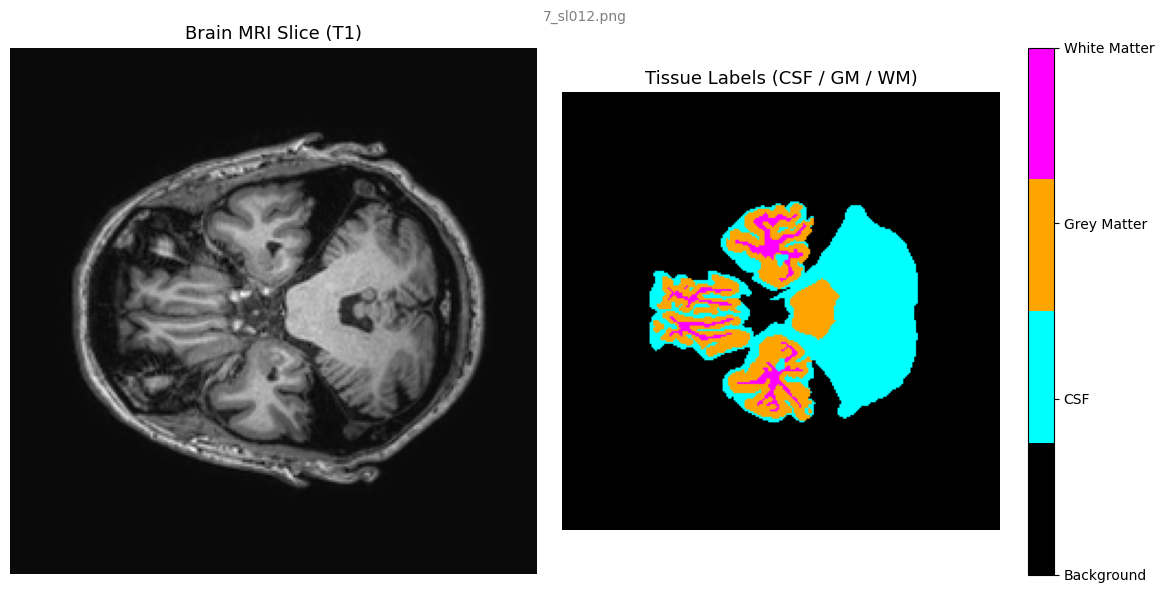

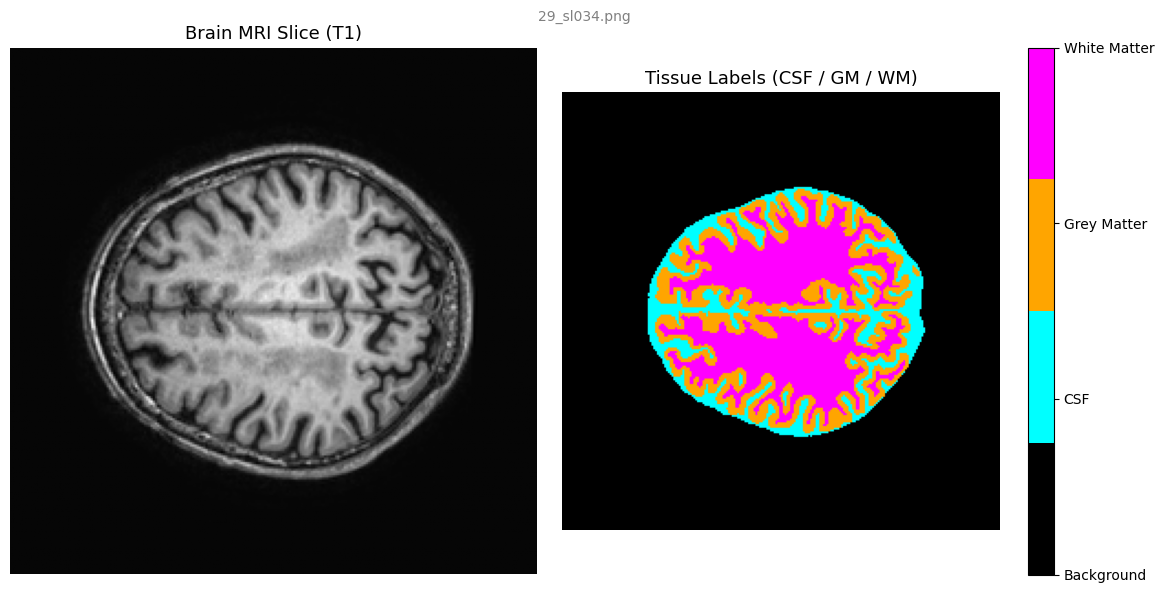

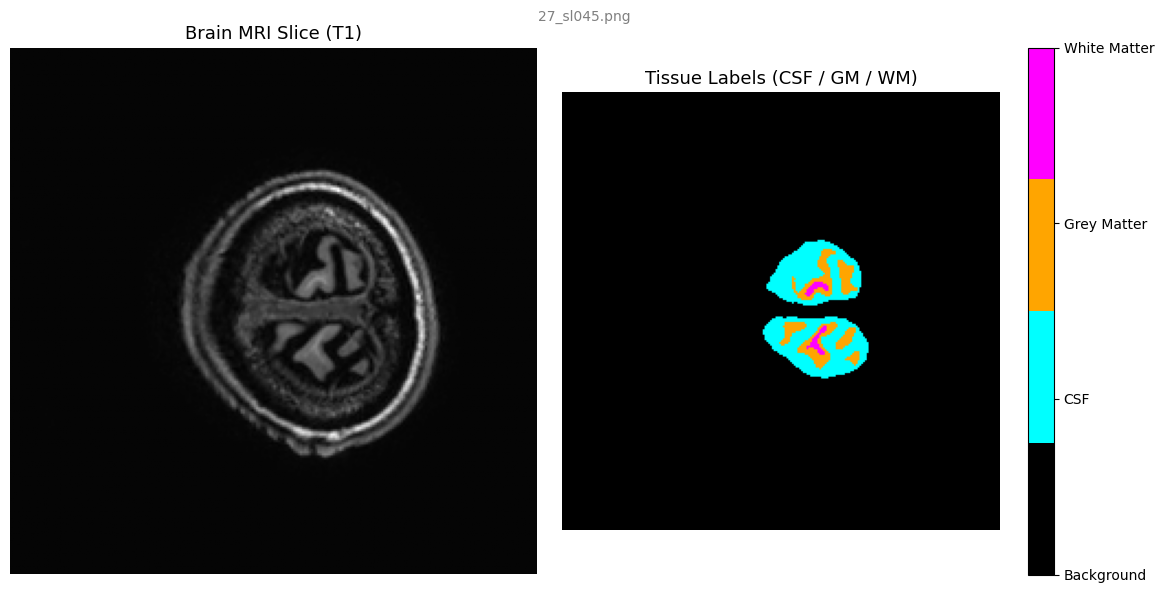

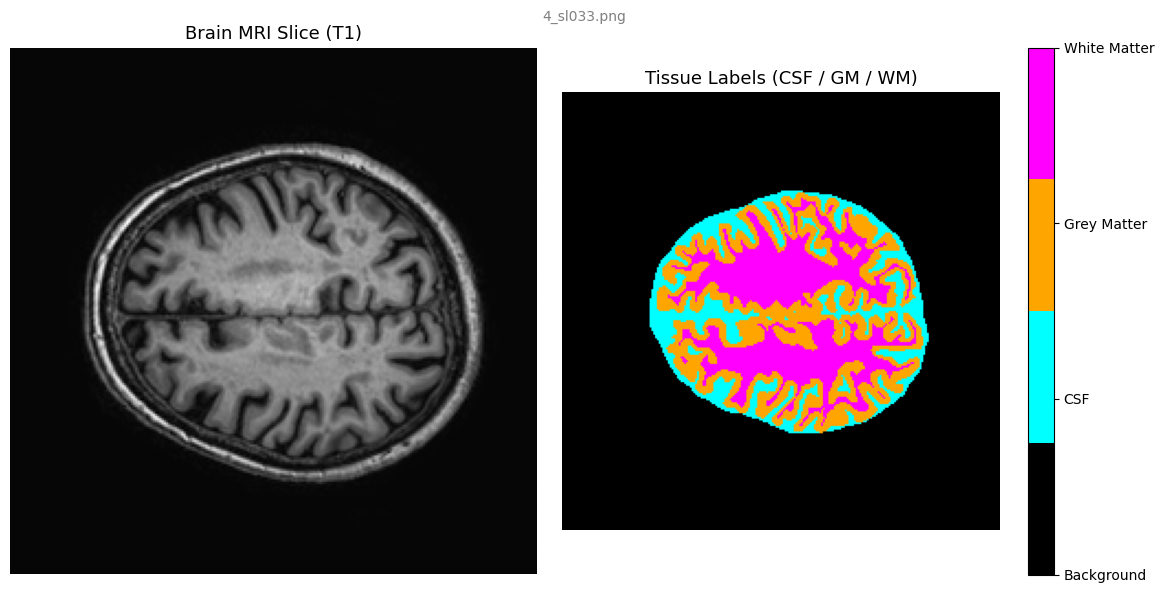

In [ ]:
CLASS_COLORS = ['black', 'cyan', 'orange', 'magenta']
cmap_classes = mcolors.ListedColormap(CLASS_COLORS)

def visualize_sample(image_name):
    img  = cv2.imread(os.path.join(IMAGE_FOLDER, image_name), cv2.IMREAD_GRAYSCALE)
    mask = cv2.imread(os.path.join(MASK_FOLDER,  image_name), cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title('Brain MRI Slice (T1)', fontsize=13)

    im = axes[1].imshow(mask, cmap=cmap_classes, vmin=0, vmax=NUM_CLASSES - 1)
    axes[1].set_title('Tissue Labels (CSF / GM / WM)', fontsize=13)
    cbar = plt.colorbar(im, ax=axes[1], ticks=range(NUM_CLASSES))
    cbar.ax.set_yticklabels(CLASS_NAMES)

    for ax in axes: ax.axis('off')
    plt.suptitle(image_name, fontsize=10, color='gray')
    plt.tight_layout()
    plt.show()


all_images = os.listdir(IMAGE_FOLDER)
for _ in range(4):
    visualize_sample(random.choice(all_images))

## 5. Train / Test Split

In [ ]:
images = sorted([f for f in os.listdir(IMAGE_FOLDER) if f.endswith('.png')])
masks  = sorted([f for f in os.listdir(MASK_FOLDER)  if f.endswith('.png')])

assert images == masks, 'Image-mask mismatch!'

train_imgs, test_imgs = train_test_split(images, test_size=TEST_SPLIT, random_state=SEED)
print(f'Train: {len(train_imgs)}  |  Test: {len(test_imgs)}')

def copy_files(file_list, src_img, src_mask, dst_img, dst_mask):
    for f in tqdm(file_list, leave=False):
        shutil.copy(os.path.join(src_img,  f), os.path.join(dst_img,  f))
        shutil.copy(os.path.join(src_mask, f), os.path.join(dst_mask, f))

copy_files(train_imgs, IMAGE_FOLDER, MASK_FOLDER, TRAIN_IMG_DIR, TRAIN_MASK_DIR)
copy_files(test_imgs,  IMAGE_FOLDER, MASK_FOLDER, TEST_IMG_DIR,  TEST_MASK_DIR)
print('Files copied ✓')

Train: 268  |  Test: 68


Files copied ✓


## 6. tf.data Pipeline — with stronger augmentation (small dataset)

In [ ]:
def load_image(img_path, mask_path):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE, method='bilinear')
    img = tf.cast(img, tf.float32) / 255.0

    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_png(mask, channels=1)
    mask = tf.image.resize(mask, IMG_SIZE, method='nearest')
    mask = tf.cast(mask, tf.int32)
    mask = tf.squeeze(mask, axis=-1)
    mask = tf.one_hot(mask, depth=NUM_CLASSES)
    mask = tf.cast(mask, tf.float32)
    return img, mask


def augment(img, mask):
    # Stronger augmentation since dataset is small (7 subjects)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_left_right(img)
        mask = tf.image.flip_left_right(mask)
    if tf.random.uniform(()) > 0.5:
        img  = tf.image.flip_up_down(img)
        mask = tf.image.flip_up_down(mask)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, mask


def build_dataset(img_dir, mask_dir, augment_data=False, batch=BATCH_SIZE):
    img_files  = sorted([os.path.join(img_dir,  f) for f in os.listdir(img_dir)  if f.endswith('.png')])
    mask_files = sorted([os.path.join(mask_dir, f) for f in os.listdir(mask_dir) if f.endswith('.png')])
    ds = tf.data.Dataset.from_tensor_slices((img_files, mask_files))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch).prefetch(tf.data.AUTOTUNE)
    return ds


train_dataset = build_dataset(TRAIN_IMG_DIR, TRAIN_MASK_DIR, augment_data=True)
test_dataset  = build_dataset(TEST_IMG_DIR,  TEST_MASK_DIR,  augment_data=False)

print('Datasets ready ✓')
for imgs, masks in train_dataset.take(1):
    print('Batch shapes → images:', imgs.shape, ' masks:', masks.shape)

Datasets ready ✓
Batch shapes → images: (8, 224, 224, 3)  masks: (8, 224, 224, 4)


## 7. Model — SegNet (pooling-index unpooling), 4-class softmax output
**No skip connections** — uses stored max-pooling indices for unpooling. Built from scratch (no pretrained weights).

In [ ]:
class MaxPoolingWithIndices(Layer):
    def call(self, x):
        pooled, indices = tf.nn.max_pool_with_argmax(
            x, ksize=2, strides=2, padding='SAME', include_batch_in_index=True)
        return pooled, indices

class MaxUnpooling(Layer):
    def __init__(self, h, w, c, **kwargs):
        super().__init__(**kwargs)
        self.h=h; self.w=w; self.c=c
    def call(self, inputs):
        x, indices = inputs
        batch_size = tf.shape(x)[0]
        flat_x = tf.reshape(x, [-1])
        flat_indices = tf.reshape(indices, [-1, 1])
        flat_out = tf.scatter_nd(flat_indices, flat_x, [batch_size*self.h*self.w*self.c])
        return tf.reshape(flat_out, [batch_size, self.h, self.w, self.c])
    def get_config(self):
        cfg=super().get_config(); cfg.update({'h':self.h,'w':self.w,'c':self.c}); return cfg

def conv_bn_relu(x, filters, name_prefix, n=1):
    for i in range(n):
        x=Conv2D(filters,(3,3),padding='same',name=f'{name_prefix}_c{i+1}')(x)
        x=BatchNormalization(name=f'{name_prefix}_bn{i+1}')(x)
        x=Activation('relu',name=f'{name_prefix}_act{i+1}')(x)
    return x

def build_model(input_shape=(224,224,3), num_classes=4):
    inputs=Input(shape=input_shape,name='input')
    pool_layer=MaxPoolingWithIndices()
    e1=conv_bn_relu(inputs,64,'enc1',n=2); h1,w1,c1=e1.shape[1],e1.shape[2],e1.shape[3]; p1,idx1=pool_layer(e1)
    e2=conv_bn_relu(p1,128,'enc2',n=2); h2,w2,c2=e2.shape[1],e2.shape[2],e2.shape[3]; p2,idx2=pool_layer(e2)
    e3=conv_bn_relu(p2,256,'enc3',n=3); h3,w3,c3=e3.shape[1],e3.shape[2],e3.shape[3]; p3,idx3=pool_layer(e3)
    e4=conv_bn_relu(p3,512,'enc4',n=3); h4,w4,c4=e4.shape[1],e4.shape[2],e4.shape[3]; p4,idx4=pool_layer(e4)
    e5=conv_bn_relu(p4,512,'enc5',n=3); h5,w5,c5=e5.shape[1],e5.shape[2],e5.shape[3]; p5,idx5=pool_layer(e5)
    x=Dropout(0.3,name='bottleneck_drop')(p5)
    d5=MaxUnpooling(h5,w5,c5,name='unpool5')([x,idx5]); d5=conv_bn_relu(d5,512,'dec5',n=3)
    d4=MaxUnpooling(h4,w4,c4,name='unpool4')([d5,idx4]); d4=conv_bn_relu(d4,256,'dec4',n=3)
    d3=MaxUnpooling(h3,w3,c3,name='unpool3')([d4,idx3]); d3=conv_bn_relu(d3,128,'dec3',n=3)
    d2=MaxUnpooling(h2,w2,c2,name='unpool2')([d3,idx2]); d2=conv_bn_relu(d2,64,'dec2',n=2)
    d1=MaxUnpooling(h1,w1,c1,name='unpool1')([d2,idx1]); d1=conv_bn_relu(d1,64,'dec1',n=2)
    output=Conv2D(num_classes,(1,1),activation='softmax',name='output')(d1)
    return Model(inputs=inputs,outputs=output,name='SegNet_MultiClass_MRBrainS18')

model=build_model(input_shape=(*IMG_SIZE,3),num_classes=NUM_CLASSES)
print('Model built')
print(f'Total parameters     : {model.count_params():,}')
print(f'Trainable parameters : {sum([K.count_params(w) for w in model.trainable_weights]):,}')

Model built
Total parameters     : 24,957,892
Trainable parameters : 24,943,556


## 8. Custom Metrics & Loss

In [ ]:
def dice_coefficient_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    union = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0)
    return K.mean((2.0 * intersection + smooth) / (union + smooth))

def dice_loss_multiclass(y_true, y_pred):
    return 1.0 - dice_coefficient_multiclass(y_true, y_pred)

def iou_score_multiclass(y_true, y_pred, smooth=1.0):
    y_true_f = K.reshape(y_true, [-1, NUM_CLASSES])
    y_pred_f = K.reshape(y_pred, [-1, NUM_CLASSES])
    intersection = K.sum(y_true_f * y_pred_f, axis=0)
    total = K.sum(y_true_f, axis=0) + K.sum(y_pred_f, axis=0) - intersection
    return K.mean((intersection + smooth) / (total + smooth))

def csf_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 1]; p = y_pred[..., 1]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def gm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 2]; p = y_pred[..., 2]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def wm_iou(y_true, y_pred, smooth=1.0):
    t = y_true[..., 3]; p = y_pred[..., 3]
    i = K.sum(t * p)
    return (i + smooth) / (K.sum(t) + K.sum(p) - i + smooth)

def pixel_accuracy_multiclass(y_true, y_pred):
    return K.mean(K.cast(K.equal(K.argmax(y_true, axis=-1), K.argmax(y_pred, axis=-1)), K.floatx()))

def combined_loss_multiclass(y_true, y_pred):
    return dice_loss_multiclass(y_true, y_pred) + tf.keras.losses.categorical_crossentropy(y_true, y_pred)


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=combined_loss_multiclass,
    metrics=[dice_coefficient_multiclass, iou_score_multiclass,
             pixel_accuracy_multiclass, csf_iou, gm_iou, wm_iou],
      jit_compile=False
)
print('Model compiled ✓')

Model compiled ✓


## 9. Model Summary

In [ ]:
model.summary()
try:
    tf.keras.utils.plot_model(model, to_file='segnet_mrbrains_architecture.png',
                               show_shapes=True, show_layer_names=True, dpi=64)
    print('Architecture diagram saved ✓')
except Exception as e:
    print('Architecture plot skipped:', str(e)[:100])

Model: "SegNet_MultiClass_MRBrainS18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c1 (Conv2D)    │ (None, 224, 224,  │      1,792 │ input[0][0]       │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 224, 224,  │        256 │ enc1_c1[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act1           │ (None, 224, 224,  │          0 │ enc1_bn1[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c2 (Conv2D)    │ (None, 224, 224,  │     36,928 │ enc1_act1[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 224, 224,  │        256 │ enc1_c2[0][0]     │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_act2           │ (None, 224, 224,  │          0 │ enc1_bn2[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling_with_i… │ [(None, 7, 7,     │          0 │ enc1_act2[0][0],  │
│ (MaxPoolingWithInd… │ 512), (None, 7,   │            │ enc2_act2[0][0],  │
│                     │ 7, 512)]          │            │ enc3_act3[0][0],  │
│                     │                   │            │ enc4_act3[0][0],  │
│                     │                   │            │ enc5_act3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c1 (Conv2D)    │ (None, 112, 112,  │     73,856 │ max_pooling_with… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 112, 112,  │        512 │ enc2_c1[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act1           │ (None, 112, 112,  │          0 │ enc2_bn1[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c2 (Conv2D)    │ (None, 112, 112,  │    147,584 │ enc2_act1[0][0]   │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 112, 112,  │        512 │ enc2_c2[0][0]     │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_act2           │ (None, 112, 112,  │          0 │ enc2_bn2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c1 (Conv2D)    │ (None, 56, 56,    │    295,168 │ max_pooling_with… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 56, 56,    │      1,024 │ enc3_c1[0][0]   

 Total params: 24,957,892 (95.21 MB)

 Trainable params: 24,943,556 (95.15 MB)

 Non-trainable params: 14,336 (56.00 KB)

Architecture diagram saved ✓


## 10. Callbacks (EarlyStopping disabled)

In [ ]:
def decode_mask(onehot_mask):
    return tf.argmax(onehot_mask, axis=-1)

def colorize_mask(label_map):
    colors = np.array([[0,0,0],[0,255,255],[255,165,0],[255,0,255]], dtype=np.uint8)
    return colors[np.array(label_map).astype(int)]

def show_predictions(dataset, num=3, model_to_use=None):
    m = model_to_use or model
    for imgs, masks in dataset.take(1):
        preds = m.predict(imgs, verbose=0)
        for i in range(min(num, len(imgs))):
            fig, axes = plt.subplots(1, 3, figsize=(13, 4))
            axes[0].imshow(imgs[i].numpy());                              axes[0].set_title('Input MRI')
            axes[1].imshow(colorize_mask(decode_mask(masks[i]).numpy())); axes[1].set_title('Ground Truth')
            axes[2].imshow(colorize_mask(decode_mask(preds[i]).numpy())); axes[2].set_title('Prediction')
            for ax in axes: ax.axis('off')
            plt.tight_layout(); plt.show()

class DisplayCallback(callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 10 == 0:
            show_predictions(test_dataset, num=2)
            print(f'Prediction after epoch {epoch + 1}\n')

logdir = os.path.join('logs', datetime.datetime.now().strftime('%Y%m%d-%H%M%S'))

callbacks_list = [
    DisplayCallback(),
    callbacks.TensorBoard(logdir, histogram_freq=1),
    callbacks.ModelCheckpoint('best_model_segnet_mrbrains.keras', verbose=1,
                               save_best_only=True, monitor='val_iou_score_multiclass', mode='max'),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1),
    # EarlyStopping intentionally removed
]
print('Callbacks ready ✓ (no EarlyStopping — will run all', EPOCHS, 'epochs)')

Callbacks ready ✓ (no EarlyStopping — will run all 100 epochs)


## 11. Initial Predictions (before training)

Predictions before training:


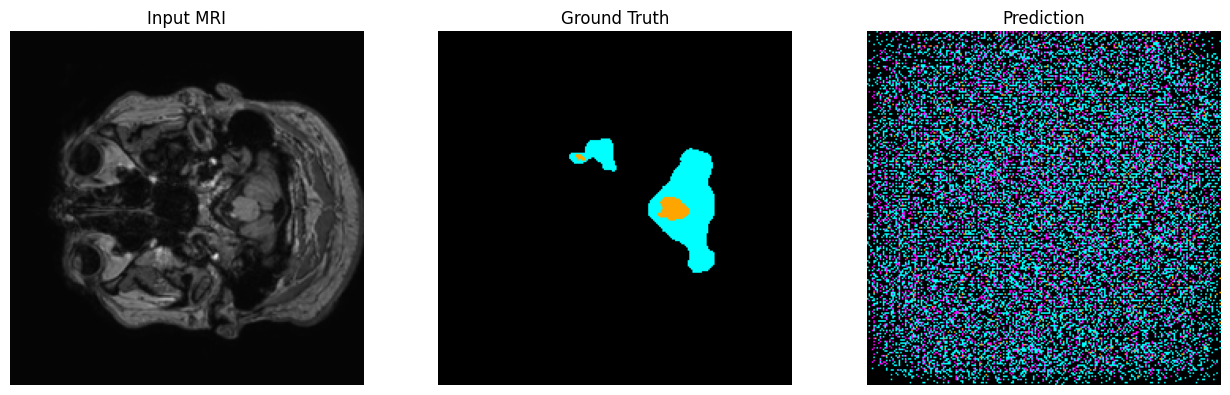

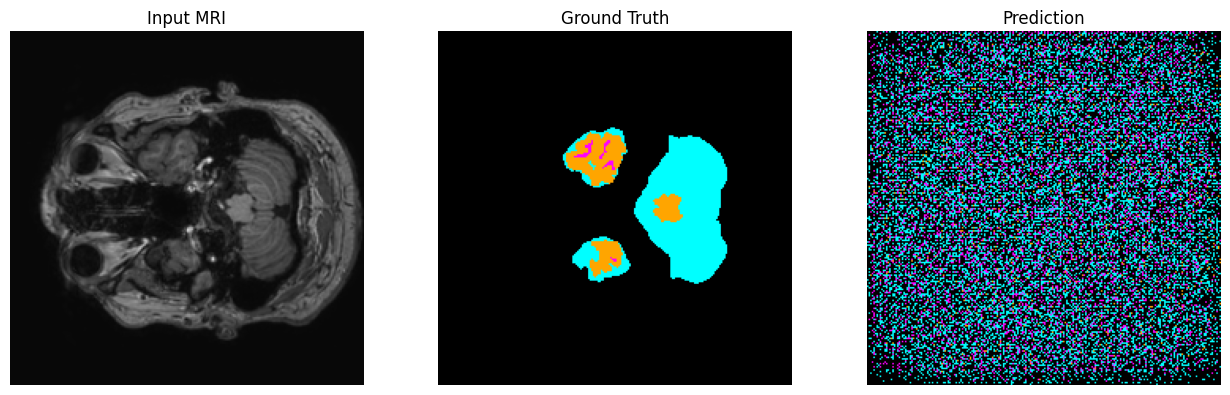

In [ ]:
print('Predictions before training:')
show_predictions(test_dataset, num=2)

## 12. Training

Steps per epoch  : 33
Validation steps : 8
Epoch 1/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - csf_iou: 0.0684 - dice_coefficient_multiclass: 0.1992 - gm_iou: 0.0573 - iou_score_multiclass: 0.1233 - loss: 2.1444 - pixel_accuracy_multiclass: 0.4762 - wm_iou: 0.0440
Epoch 1: val_iou_score_multiclass improved from None to 0.10601, saving model to best_model_segnet_mrbrains.keras

Epoch 1: finished saving model to best_model_segnet_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 41s 516ms/step - csf_iou: 0.0756 - dice_coefficient_multiclass: 0.2387 - gm_iou: 0.0733 - iou_score_multiclass: 0.1562 - loss: 1.8886 - pixel_accuracy_multiclass: 0.6432 - wm_iou: 0.0535 - val_csf_iou: 0.0613 - val_dice_coefficient_multiclass: 0.1800 - val_gm_iou: 0.0557 - val_iou_score_multiclass: 0.1060 - val_loss: 2.1129 - val_pixel_accuracy_multiclass: 0.8079 - val_wm_iou: 0.0416 - learning_rate: 1.0000e-04
Epoch 2/100
 1/33 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - csf_iou: 0.0105 - dice_coefficient_multiclass: 0.1805 -

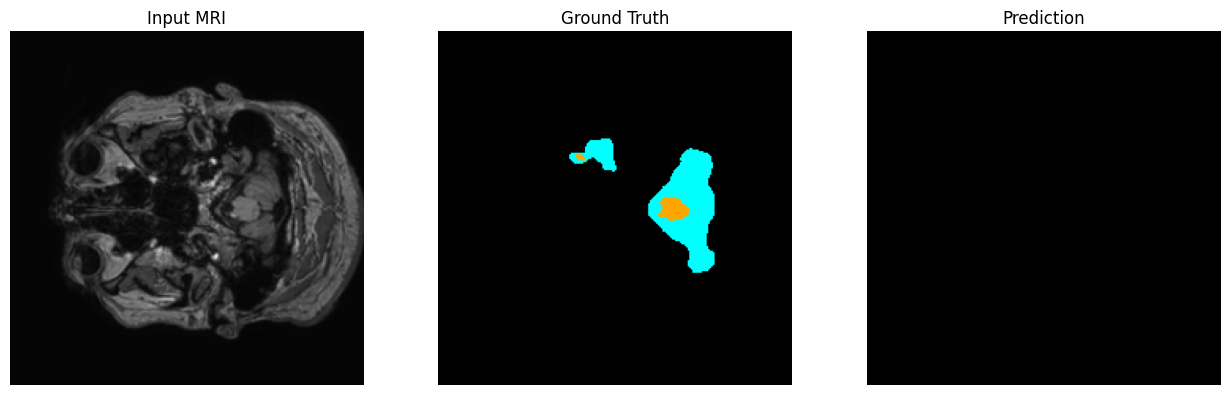

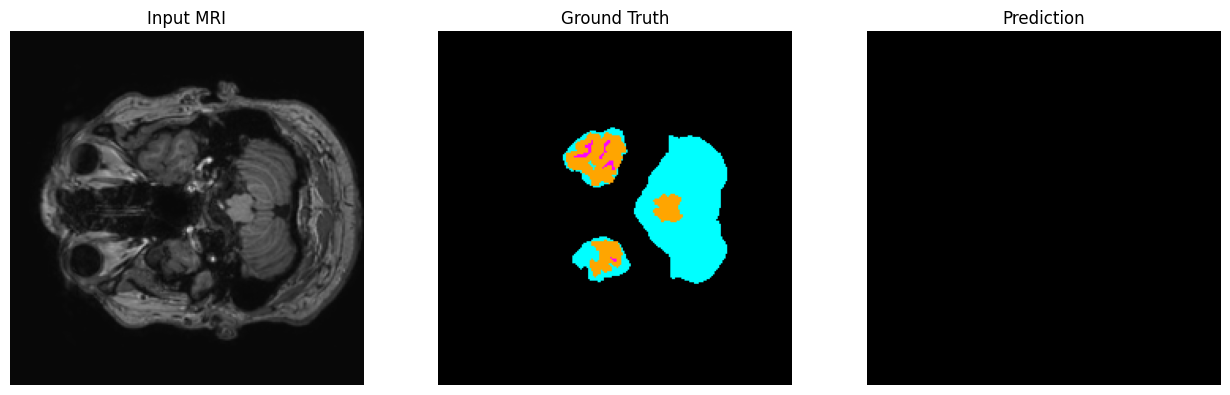

Prediction after epoch 10


Epoch 10: val_iou_score_multiclass improved from 0.18870 to 0.18883, saving model to best_model_segnet_mrbrains.keras

Epoch 10: finished saving model to best_model_segnet_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 244ms/step - csf_iou: 0.0241 - dice_coefficient_multiclass: 0.2255 - gm_iou: 7.2319e-04 - iou_score_multiclass: 0.1923 - loss: 1.4110 - pixel_accuracy_multiclass: 0.9261 - wm_iou: 6.3164e-05 - val_csf_iou: 0.0499 - val_dice_coefficient_multiclass: 0.2551 - val_gm_iou: 0.0450 - val_iou_score_multiclass: 0.1888 - val_loss: 1.4399 - val_pixel_accuracy_multiclass: 0.8079 - val_wm_iou: 0.0371 - learning_rate: 1.0000e-04
Epoch 11/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - csf_iou: 0.2270 - dice_coefficient_multiclass: 0.4701 - gm_iou: 0.1820 - iou_score_multiclass: 0.3617 - loss: 0.8787 - pixel_accuracy_multiclass: 0.8987 - wm_iou: 0.2005
Epoch 11: val_iou_score_multiclass improved from 0.18883 to 0.19779, saving model to best_model_segnet_mrbrain

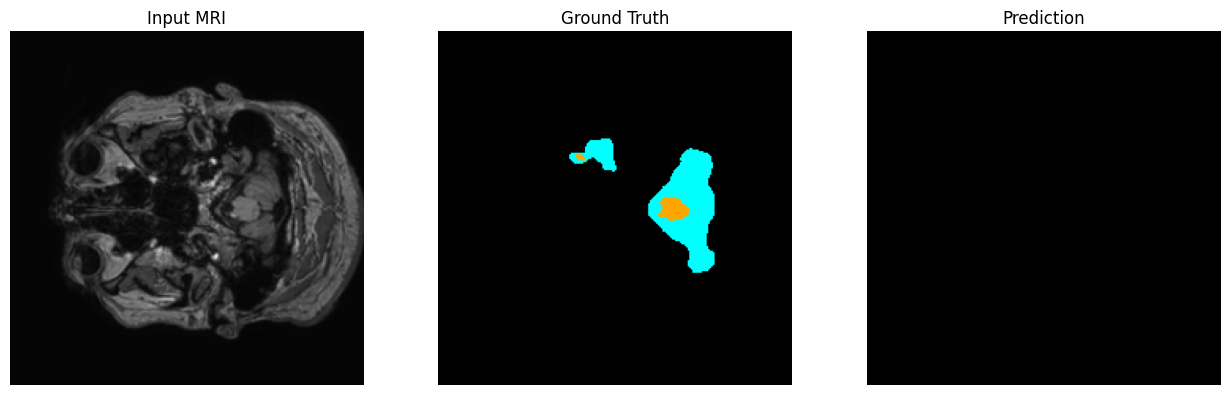

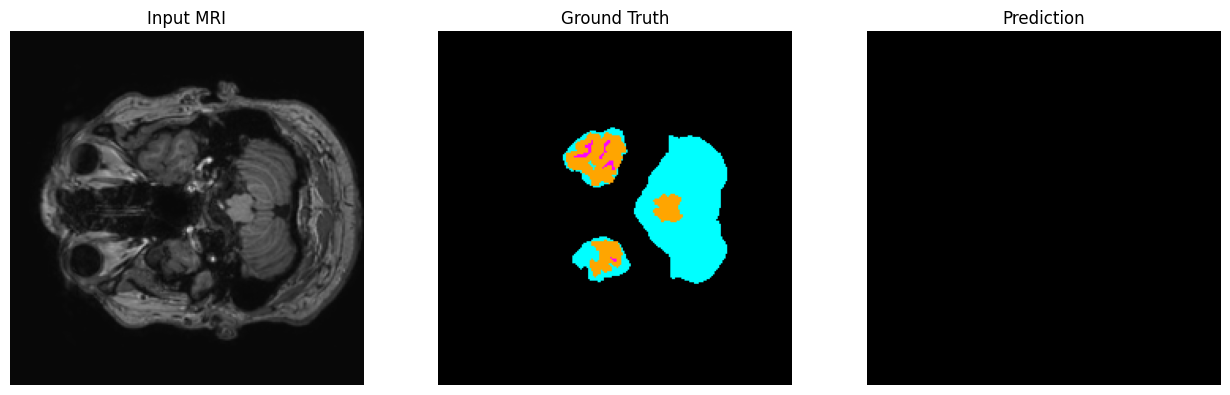

Prediction after epoch 20


Epoch 20: val_iou_score_multiclass did not improve from 0.21415
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - csf_iou: 0.0531 - dice_coefficient_multiclass: 0.2550 - gm_iou: 0.0016 - iou_score_multiclass: 0.2250 - loss: 1.1270 - pixel_accuracy_multiclass: 0.9741 - wm_iou: 1.0792e-04 - val_csf_iou: 0.0348 - val_dice_coefficient_multiclass: 0.2544 - val_gm_iou: 0.0213 - val_iou_score_multiclass: 0.2092 - val_loss: 1.4729 - val_pixel_accuracy_multiclass: 0.8088 - val_wm_iou: 0.0246 - learning_rate: 1.0000e-04
Epoch 21/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - csf_iou: 0.3580 - dice_coefficient_multiclass: 0.5790 - gm_iou: 0.2955 - iou_score_multiclass: 0.4599 - loss: 0.6576 - pixel_accuracy_multiclass: 0.9297 - wm_iou: 0.2862
Epoch 21: val_iou_score_multiclass improved from 0.21415 to 0.22468, saving model to best_model_segnet_mrbrains.keras

Epoch 21: finished saving model to best_model_segnet_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 454ms/step - csf_io

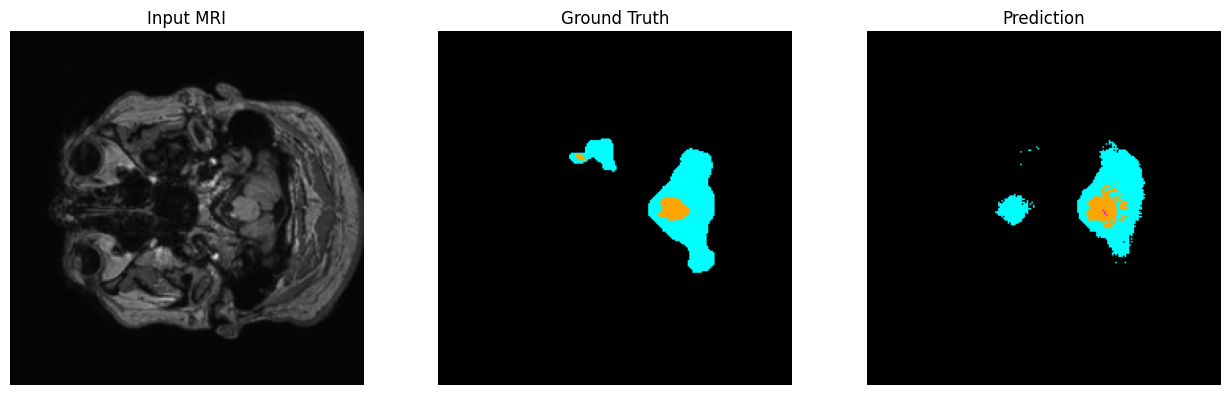

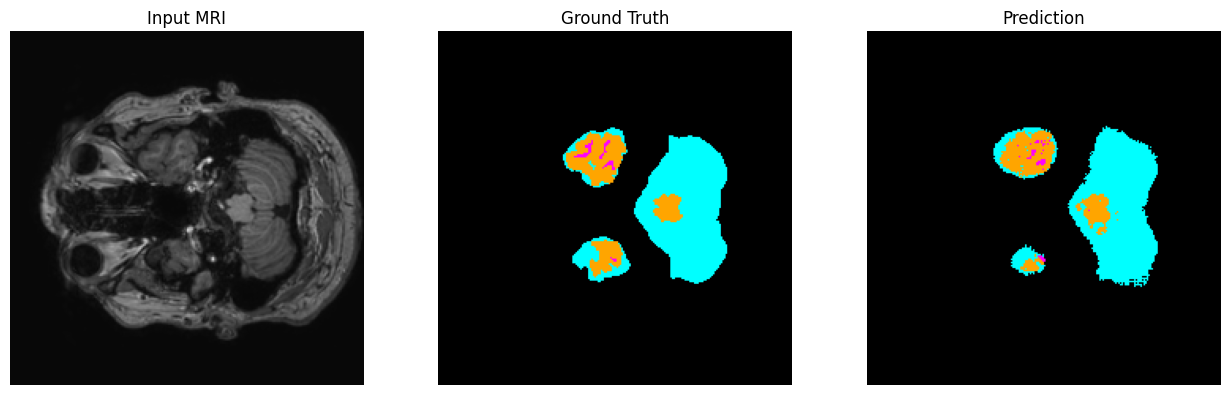

Prediction after epoch 30


Epoch 30: val_iou_score_multiclass improved from 0.49411 to 0.49577, saving model to best_model_segnet_mrbrains.keras

Epoch 30: finished saving model to best_model_segnet_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 242ms/step - csf_iou: 0.0906 - dice_coefficient_multiclass: 0.2789 - gm_iou: 9.8923e-04 - iou_score_multiclass: 0.2480 - loss: 0.9631 - pixel_accuracy_multiclass: 0.9863 - wm_iou: 1.6828e-04 - val_csf_iou: 0.3772 - val_dice_coefficient_multiclass: 0.6302 - val_gm_iou: 0.3039 - val_iou_score_multiclass: 0.4958 - val_loss: 0.6057 - val_pixel_accuracy_multiclass: 0.9232 - val_wm_iou: 0.3881 - learning_rate: 1.0000e-04
Epoch 31/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - csf_iou: 0.4421 - dice_coefficient_multiclass: 0.6400 - gm_iou: 0.3753 - iou_score_multiclass: 0.5204 - loss: 0.5476 - pixel_accuracy_multiclass: 0.9421 - wm_iou: 0.3340
Epoch 31: val_iou_score_multiclass improved from 0.49577 to 0.54572, saving model to best_model_segnet_mrbrain

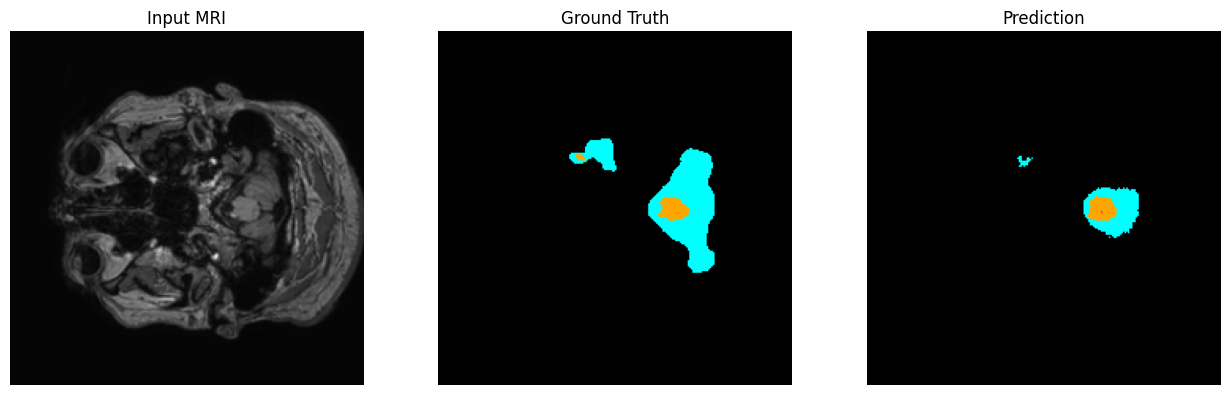

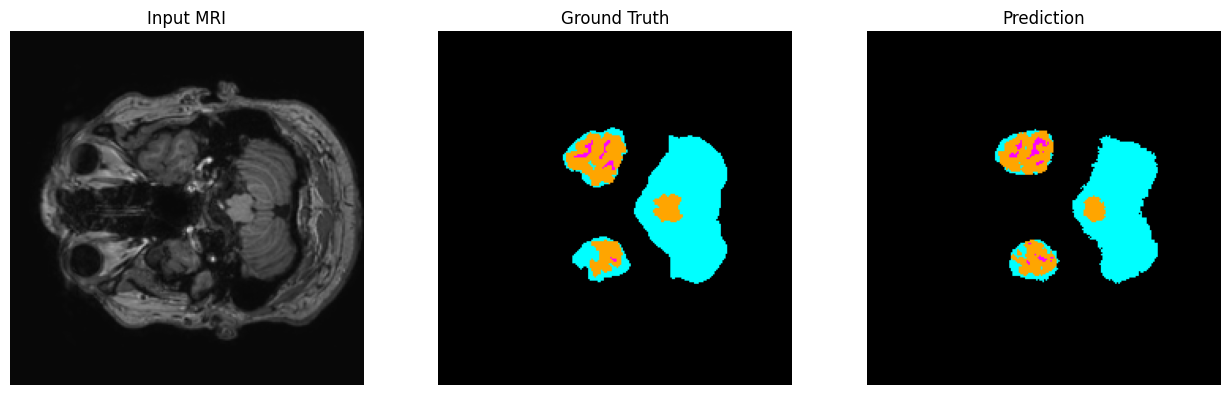

Prediction after epoch 40


Epoch 40: val_iou_score_multiclass did not improve from 0.59160
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 195ms/step - csf_iou: 0.1393 - dice_coefficient_multiclass: 0.3040 - gm_iou: 0.0029 - iou_score_multiclass: 0.2692 - loss: 0.8563 - pixel_accuracy_multiclass: 0.9951 - wm_iou: 2.4957e-04 - val_csf_iou: 0.4795 - val_dice_coefficient_multiclass: 0.7144 - val_gm_iou: 0.4258 - val_iou_score_multiclass: 0.5811 - val_loss: 0.4485 - val_pixel_accuracy_multiclass: 0.9442 - val_wm_iou: 0.4736 - learning_rate: 1.0000e-04
Epoch 41/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step - csf_iou: 0.5421 - dice_coefficient_multiclass: 0.7145 - gm_iou: 0.4925 - iou_score_multiclass: 0.5981 - loss: 0.4211 - pixel_accuracy_multiclass: 0.9566 - wm_iou: 0.4035
Epoch 41: val_iou_score_multiclass improved from 0.59160 to 0.60365, saving model to best_model_segnet_mrbrains.keras

Epoch 41: finished saving model to best_model_segnet_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 15s 458ms/step - csf_io

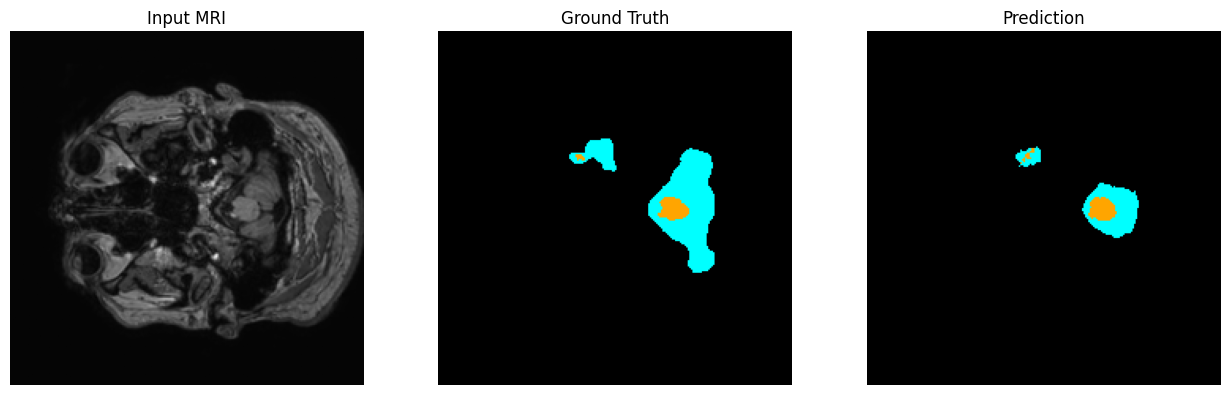

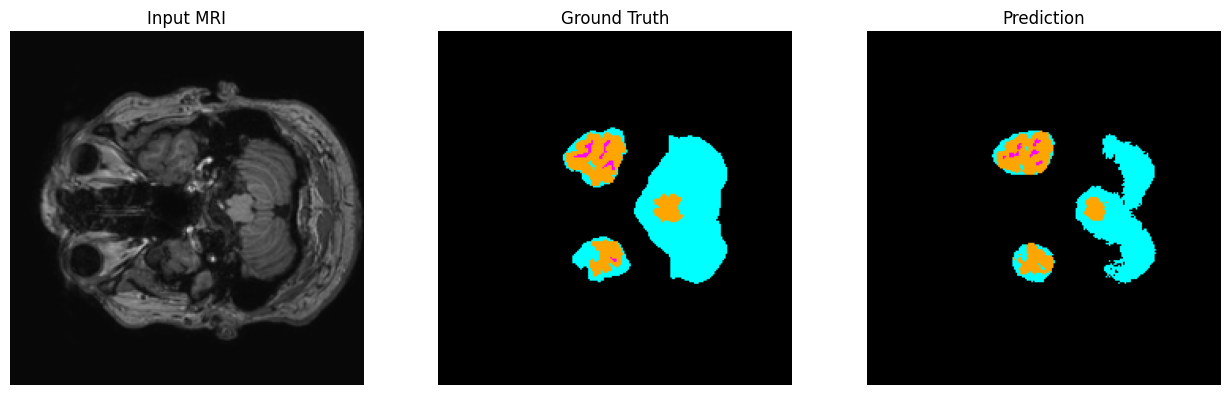

Prediction after epoch 50


Epoch 50: val_iou_score_multiclass did not improve from 0.62871
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 187ms/step - csf_iou: 0.1814 - dice_coefficient_multiclass: 0.3235 - gm_iou: 0.0048 - iou_score_multiclass: 0.2857 - loss: 0.8027 - pixel_accuracy_multiclass: 0.9955 - wm_iou: 3.8714e-04 - val_csf_iou: 0.5083 - val_dice_coefficient_multiclass: 0.7464 - val_gm_iou: 0.4998 - val_iou_score_multiclass: 0.6169 - val_loss: 0.4081 - val_pixel_accuracy_multiclass: 0.9450 - val_wm_iou: 0.5056 - learning_rate: 1.0000e-04
Epoch 51/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - csf_iou: 0.5940 - dice_coefficient_multiclass: 0.7511 - gm_iou: 0.5452 - iou_score_multiclass: 0.6388 - loss: 0.3660 - pixel_accuracy_multiclass: 0.9610 - wm_iou: 0.4497
Epoch 51: val_iou_score_multiclass did not improve from 0.62871
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 405ms/step - csf_iou: 0.5885 - dice_coefficient_multiclass: 0.7497 - gm_iou: 0.5335 - iou_score_multiclass: 0.6372 - loss: 0.3705 - pixel_accu

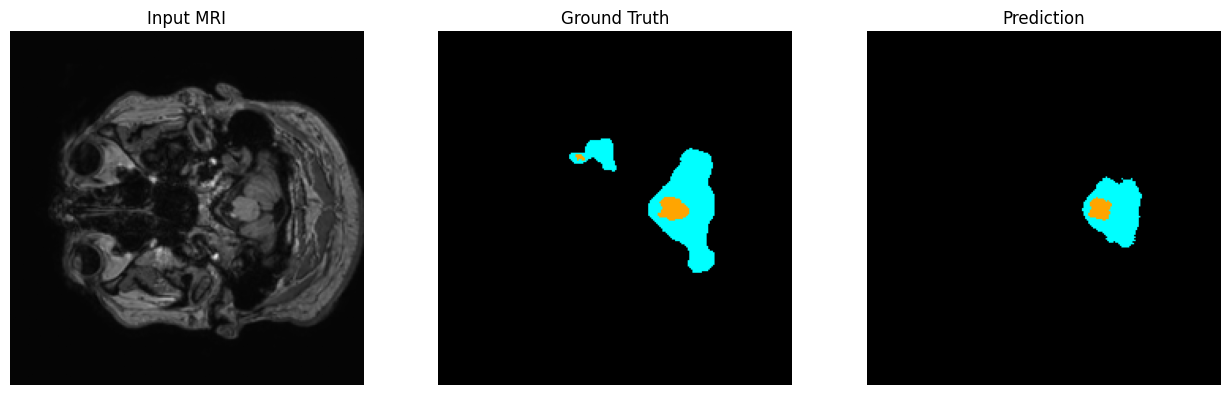

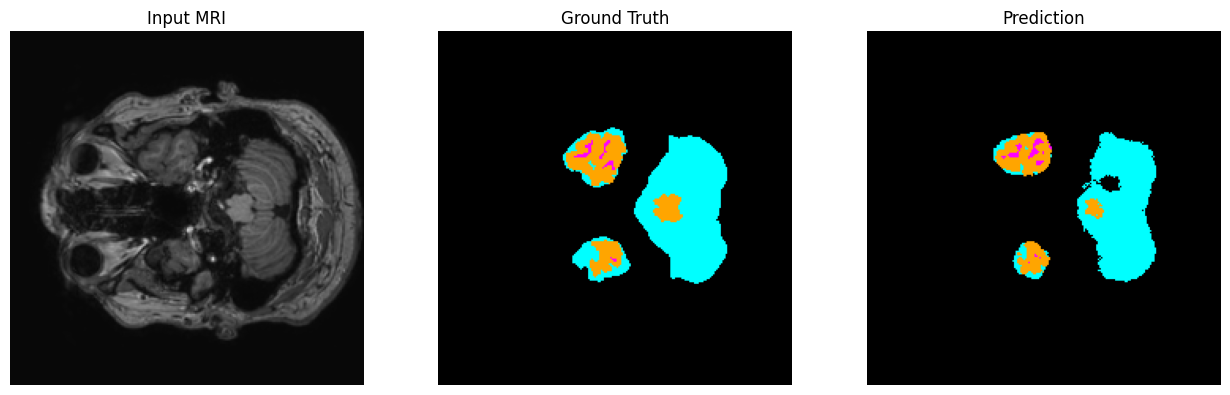

Prediction after epoch 60


Epoch 60: val_iou_score_multiclass improved from 0.67500 to 0.67667, saving model to best_model_segnet_mrbrains.keras

Epoch 60: finished saving model to best_model_segnet_mrbrains.keras
33/33 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - csf_iou: 0.2241 - dice_coefficient_multiclass: 0.3374 - gm_iou: 0.0012 - iou_score_multiclass: 0.2972 - loss: 0.7376 - pixel_accuracy_multiclass: 0.9963 - wm_iou: 4.5512e-04 - val_csf_iou: 0.5797 - val_dice_coefficient_multiclass: 0.7953 - val_gm_iou: 0.5351 - val_iou_score_multiclass: 0.6767 - val_loss: 0.3308 - val_pixel_accuracy_multiclass: 0.9560 - val_wm_iou: 0.6273 - learning_rate: 5.0000e-05
Epoch 61/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - csf_iou: 0.6216 - dice_coefficient_multiclass: 0.7718 - gm_iou: 0.5779 - iou_score_multiclass: 0.6621 - loss: 0.3353 - pixel_accuracy_multiclass: 0.9635 - wm_iou: 0.4780
Epoch 61: val_iou_score_multiclass improved from 0.67667 to 0.67759, saving model to best_model_segnet_mrbrains.ke

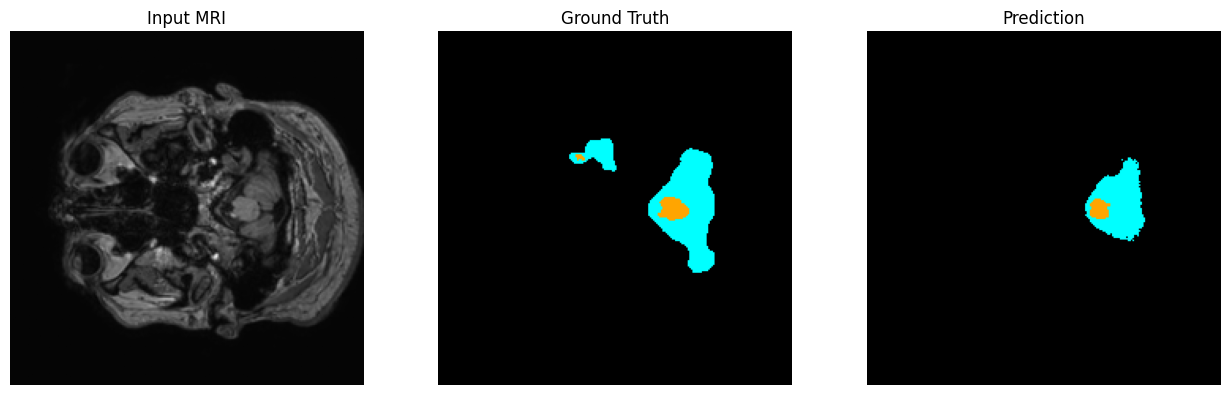

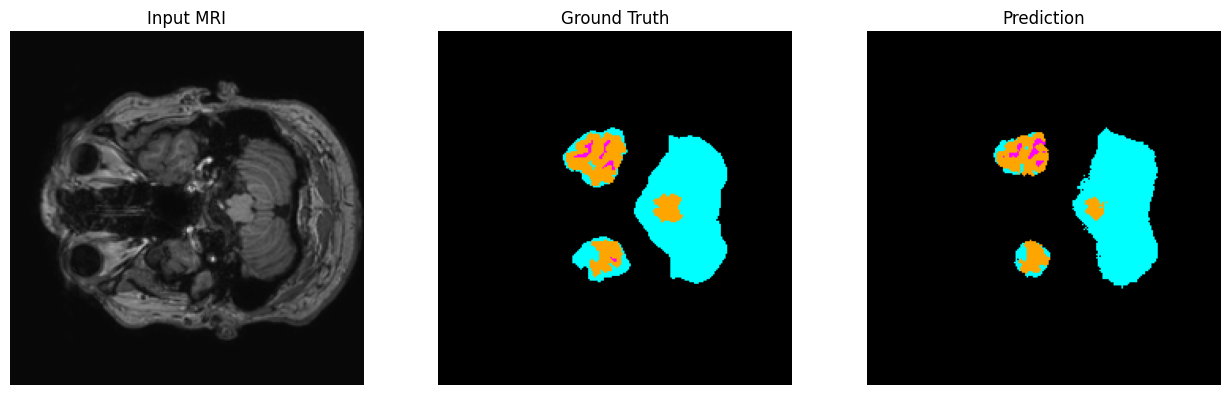

Prediction after epoch 70


Epoch 70: val_iou_score_multiclass did not improve from 0.69977
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 191ms/step - csf_iou: 0.2331 - dice_coefficient_multiclass: 0.3413 - gm_iou: 0.0014 - iou_score_multiclass: 0.3011 - loss: 0.7316 - pixel_accuracy_multiclass: 0.9960 - wm_iou: 5.5897e-04 - val_csf_iou: 0.6104 - val_dice_coefficient_multiclass: 0.8101 - val_gm_iou: 0.5540 - val_iou_score_multiclass: 0.6957 - val_loss: 0.3103 - val_pixel_accuracy_multiclass: 0.9581 - val_wm_iou: 0.6497 - learning_rate: 5.0000e-05
Epoch 71/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - csf_iou: 0.6407 - dice_coefficient_multiclass: 0.7851 - gm_iou: 0.5979 - iou_score_multiclass: 0.6779 - loss: 0.3157 - pixel_accuracy_multiclass: 0.9650 - wm_iou: 0.4986
Epoch 71: val_iou_score_multiclass did not improve from 0.69977

Epoch 71: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 404ms/step - csf_iou: 0.6348 - dice_coefficient_multiclass: 0.78

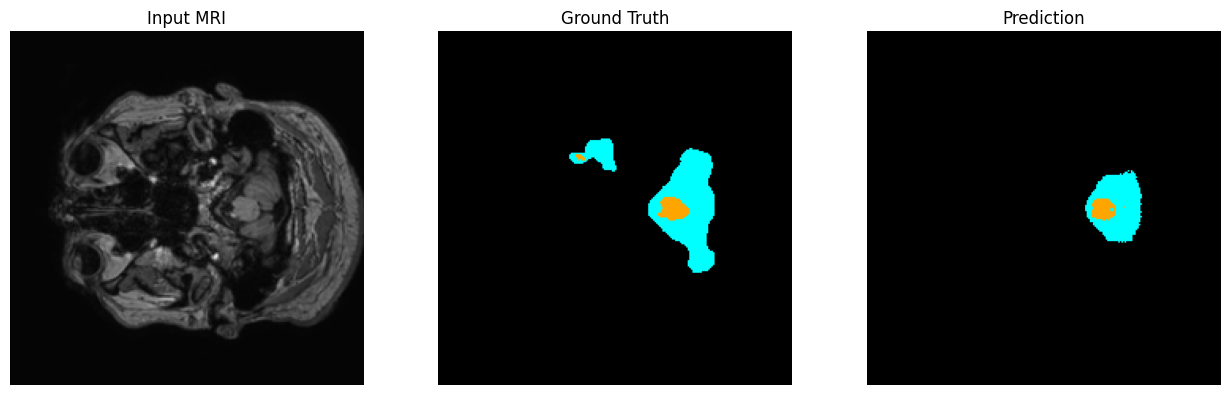

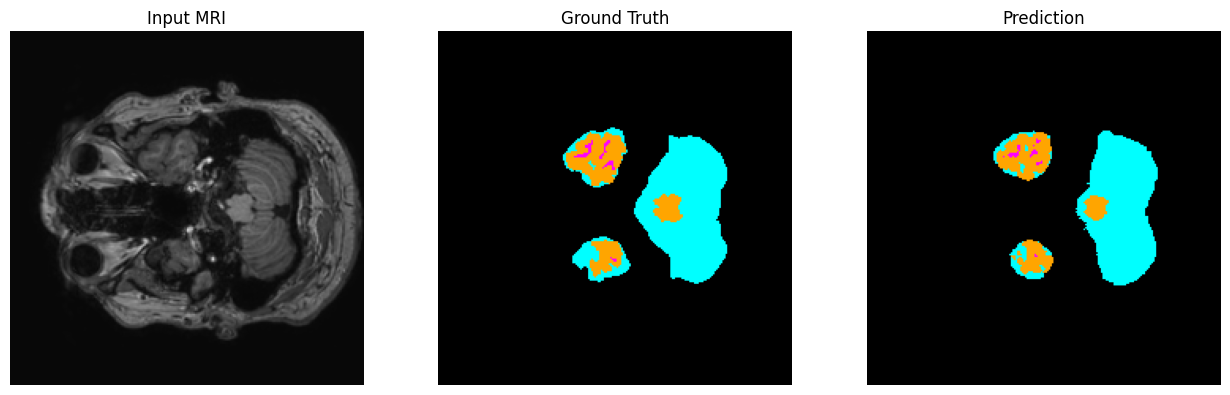

Prediction after epoch 80


Epoch 80: val_iou_score_multiclass did not improve from 0.71224
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 188ms/step - csf_iou: 0.2834 - dice_coefficient_multiclass: 0.3604 - gm_iou: 0.0072 - iou_score_multiclass: 0.3159 - loss: 0.7340 - pixel_accuracy_multiclass: 0.9967 - wm_iou: 6.1239e-04 - val_csf_iou: 0.6261 - val_dice_coefficient_multiclass: 0.8225 - val_gm_iou: 0.5961 - val_iou_score_multiclass: 0.7115 - val_loss: 0.2893 - val_pixel_accuracy_multiclass: 0.9610 - val_wm_iou: 0.6524 - learning_rate: 1.2500e-05
Epoch 81/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - csf_iou: 0.6462 - dice_coefficient_multiclass: 0.7910 - gm_iou: 0.6025 - iou_score_multiclass: 0.6843 - loss: 0.3086 - pixel_accuracy_multiclass: 0.9654 - wm_iou: 0.5128
Epoch 81: val_iou_score_multiclass did not improve from 0.71224
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 404ms/step - csf_iou: 0.6400 - dice_coefficient_multiclass: 0.7866 - gm_iou: 0.5908 - iou_score_multiclass: 0.6795 - loss: 0.3155 - pixel_accu

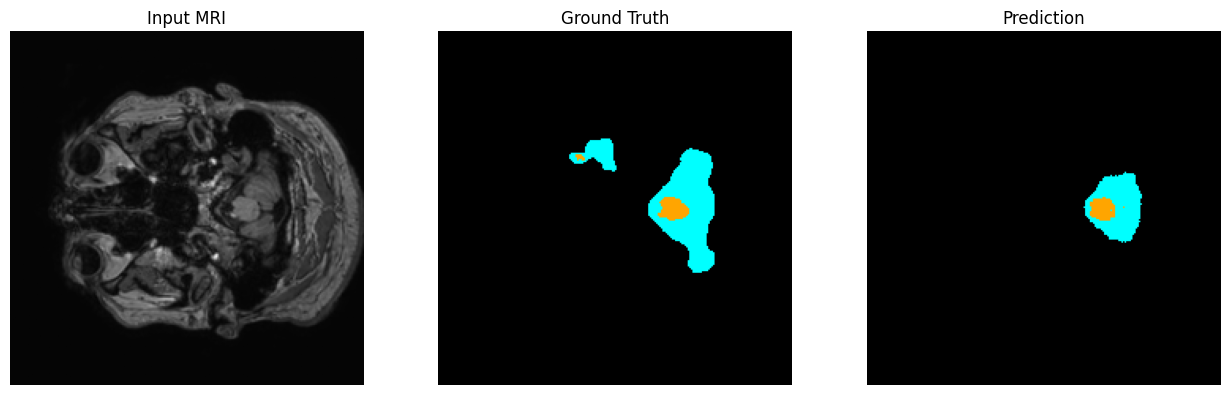

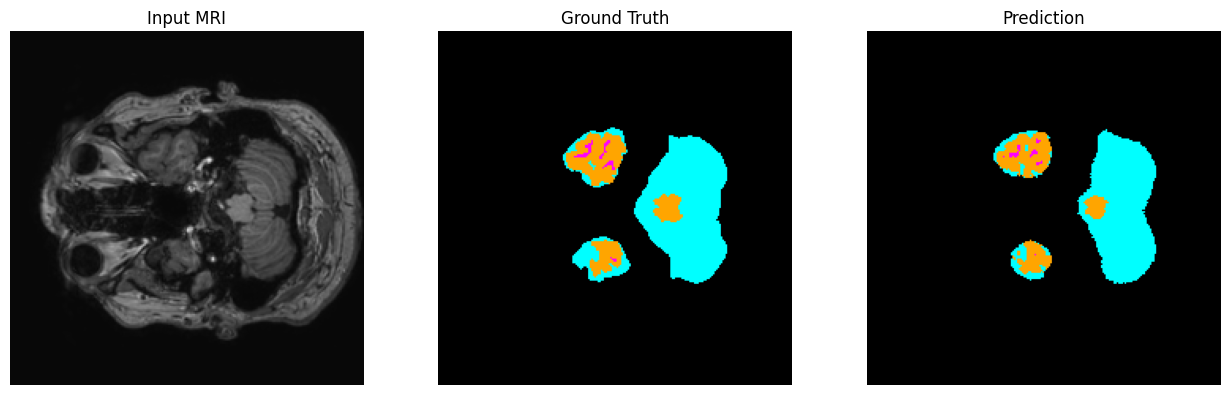

Prediction after epoch 90


Epoch 90: val_iou_score_multiclass did not improve from 0.71409
33/33 ━━━━━━━━━━━━━━━━━━━━ 6s 185ms/step - csf_iou: 0.2759 - dice_coefficient_multiclass: 0.3577 - gm_iou: 0.0061 - iou_score_multiclass: 0.3140 - loss: 0.7268 - pixel_accuracy_multiclass: 0.9963 - wm_iou: 6.7387e-04 - val_csf_iou: 0.6281 - val_dice_coefficient_multiclass: 0.8226 - val_gm_iou: 0.5948 - val_iou_score_multiclass: 0.7117 - val_loss: 0.2893 - val_pixel_accuracy_multiclass: 0.9609 - val_wm_iou: 0.6520 - learning_rate: 6.2500e-06
Epoch 91/100
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - csf_iou: 0.6548 - dice_coefficient_multiclass: 0.7949 - gm_iou: 0.6110 - iou_score_multiclass: 0.6896 - loss: 0.3007 - pixel_accuracy_multiclass: 0.9667 - wm_iou: 0.5161
Epoch 91: val_iou_score_multiclass did not improve from 0.71409
33/33 ━━━━━━━━━━━━━━━━━━━━ 13s 404ms/step - csf_iou: 0.6497 - dice_coefficient_multiclass: 0.7912 - gm_iou: 0.5986 - iou_score_multiclass: 0.6857 - loss: 0.3062 - pixel_accu

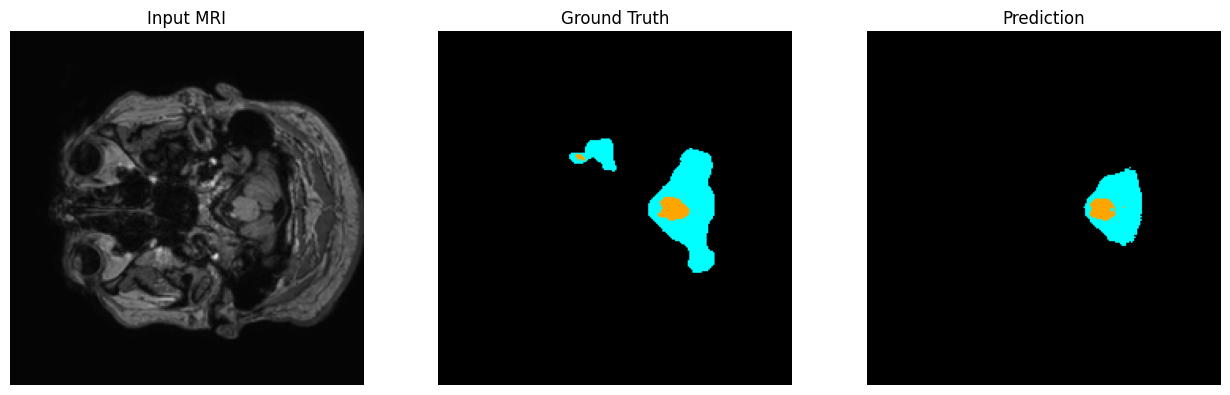

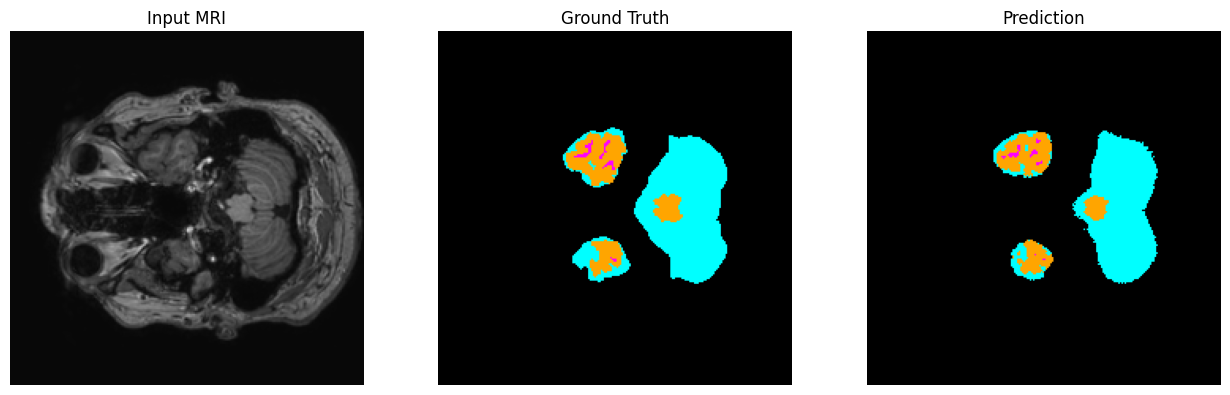

Prediction after epoch 100


Epoch 100: val_iou_score_multiclass did not improve from 0.71592
33/33 ━━━━━━━━━━━━━━━━━━━━ 7s 205ms/step - csf_iou: 0.2757 - dice_coefficient_multiclass: 0.3580 - gm_iou: 0.0065 - iou_score_multiclass: 0.3143 - loss: 0.7283 - pixel_accuracy_multiclass: 0.9961 - wm_iou: 6.8757e-04 - val_csf_iou: 0.6352 - val_dice_coefficient_multiclass: 0.8253 - val_gm_iou: 0.5980 - val_iou_score_multiclass: 0.7153 - val_loss: 0.2842 - val_pixel_accuracy_multiclass: 0.9615 - val_wm_iou: 0.6553 - learning_rate: 3.1250e-06

Training time: 17.8 min


In [ ]:
steps_per_epoch  = max(1, len(os.listdir(TRAIN_IMG_DIR)) // BATCH_SIZE)
validation_steps = max(1, len(os.listdir(TEST_IMG_DIR))  // BATCH_SIZE)

print(f'Steps per epoch  : {steps_per_epoch}')
print(f'Validation steps : {validation_steps}')

start_time = time.time()
history = model.fit(
    train_dataset, validation_data=test_dataset, epochs=EPOCHS,
    steps_per_epoch=steps_per_epoch, validation_steps=validation_steps,
    callbacks=callbacks_list
)
print(f'\nTraining time: {(time.time()-start_time)/60:.1f} min')

## 13. Training Graphs

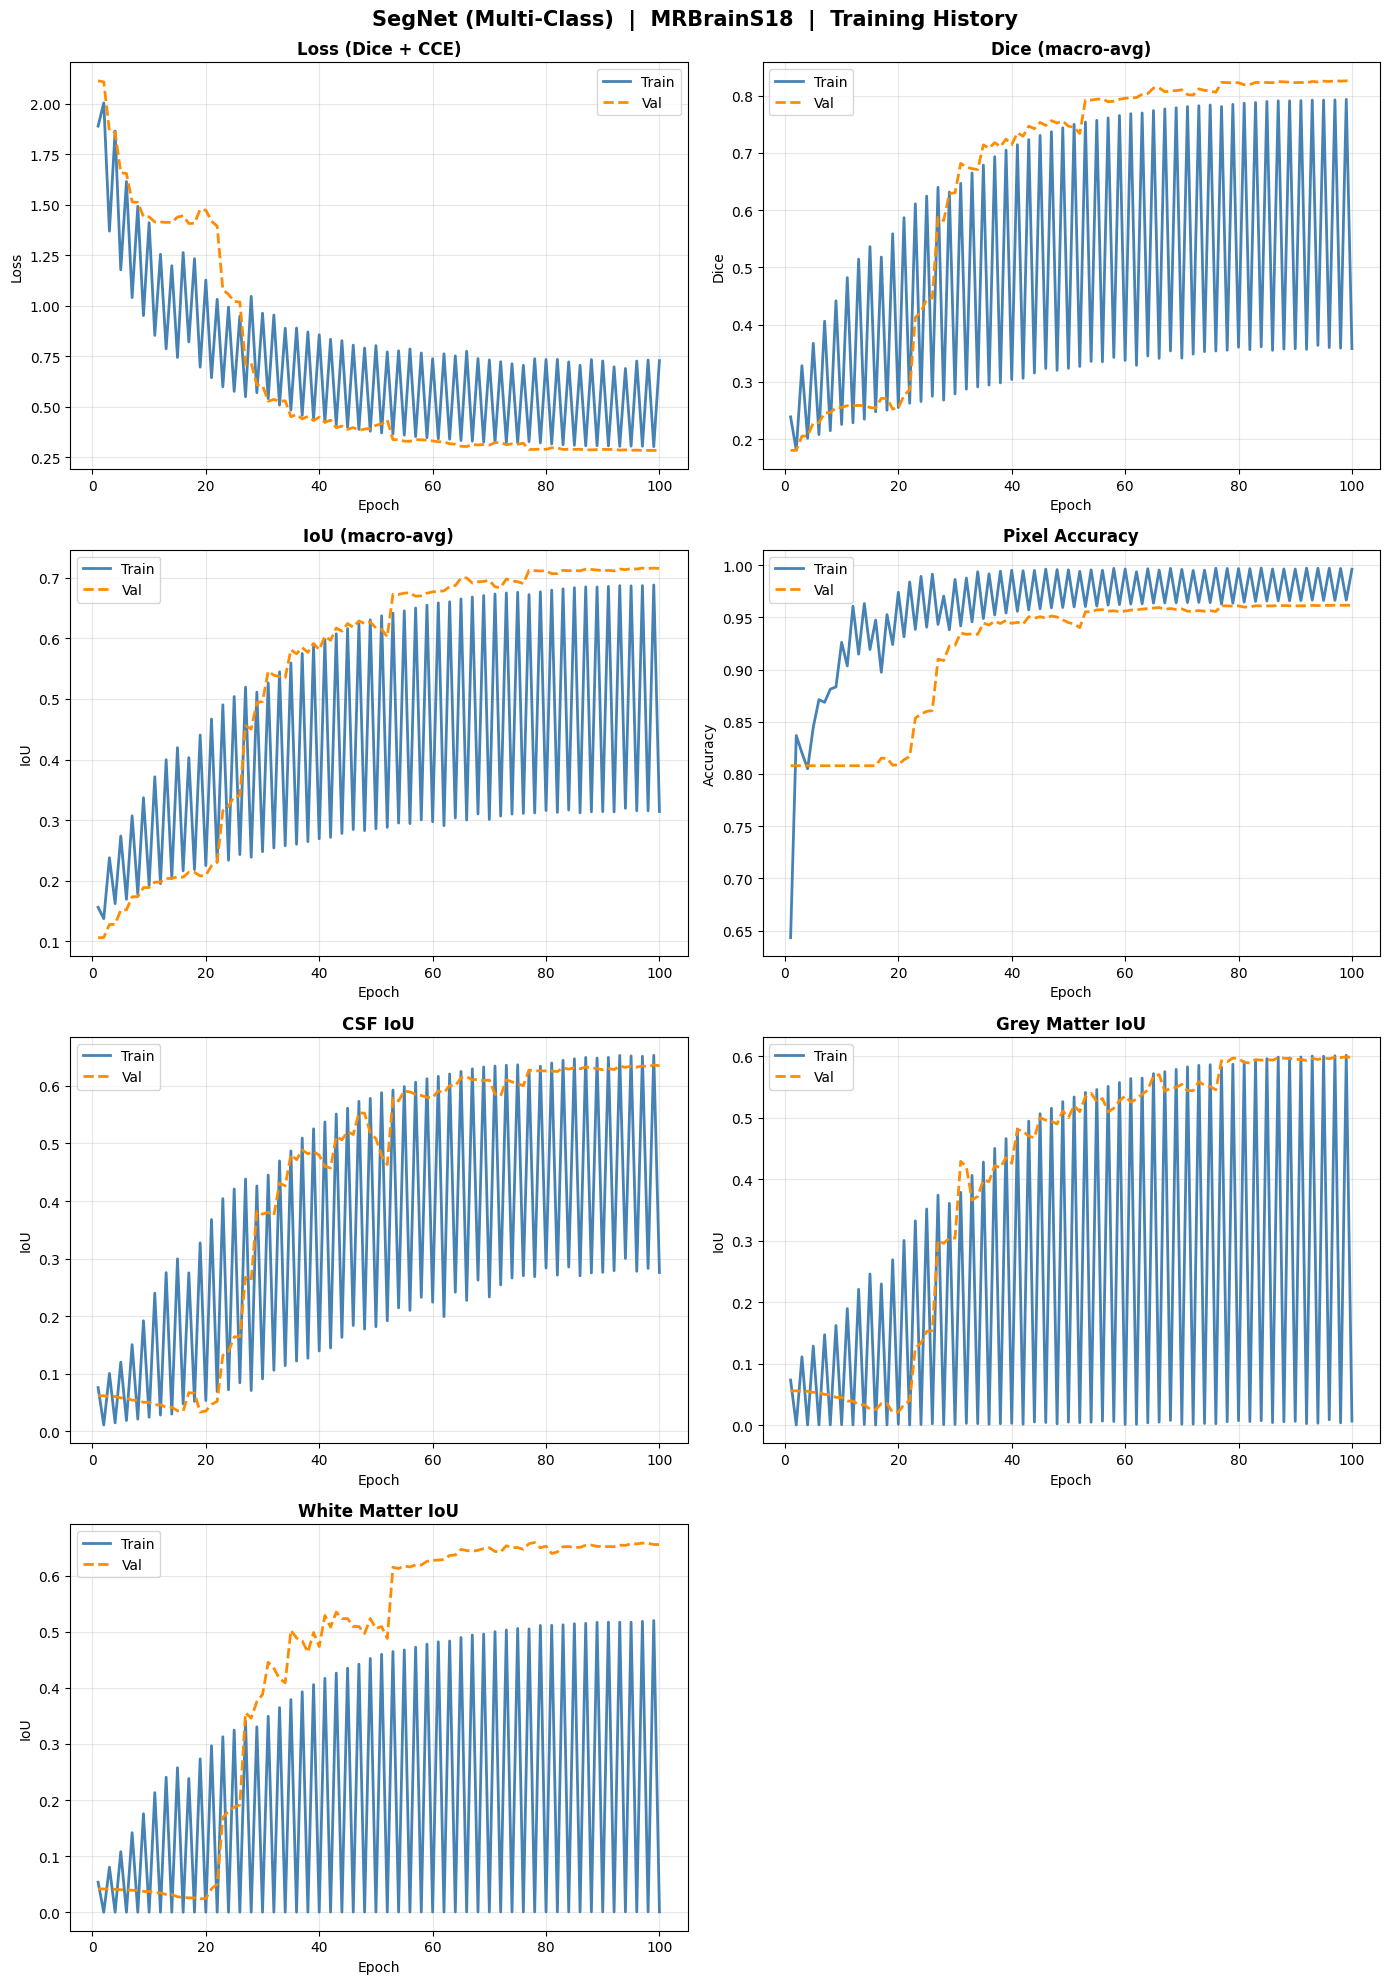

Plot saved ✓


In [ ]:
H = history.history

fig, axes = plt.subplots(4, 2, figsize=(14, 20))
fig.suptitle('SegNet (Multi-Class)  |  MRBrainS18  |  Training History',
             fontsize=15, fontweight='bold', y=0.99)

plot_specs = [
    ('loss', 'val_loss', 'Loss (Dice + CCE)', 'Loss'),
    ('dice_coefficient_multiclass', 'val_dice_coefficient_multiclass', 'Dice (macro-avg)', 'Dice'),
    ('iou_score_multiclass', 'val_iou_score_multiclass', 'IoU (macro-avg)', 'IoU'),
    ('pixel_accuracy_multiclass', 'val_pixel_accuracy_multiclass', 'Pixel Accuracy', 'Accuracy'),
    ('csf_iou', 'val_csf_iou', 'CSF IoU', 'IoU'),
    ('gm_iou', 'val_gm_iou', 'Grey Matter IoU', 'IoU'),
    ('wm_iou', 'val_wm_iou', 'White Matter IoU', 'IoU'),
]

for ax, (tk, vk, title, ylabel) in zip(axes.flatten(), plot_specs):
    er = range(1, len(H[tk]) + 1)
    ax.plot(er, H[tk], label='Train', color='steelblue', linewidth=2)
    ax.plot(er, H[vk], label='Val', color='darkorange', linewidth=2, linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(fontsize=10); ax.grid(True, alpha=0.3)

axes.flatten()[-1].axis('off')
plt.tight_layout()
plt.savefig('training_history_segnet_mrbrains.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved ✓')

## 14. Best & Average Metrics Table

In [ ]:
metric_spec = [
    ('Loss', 'loss', 'min'),
    ('Dice (macro-avg)', 'dice_coefficient_multiclass', 'max'),
    ('IoU (macro-avg)', 'iou_score_multiclass', 'max'),
    ('Pixel Accuracy', 'pixel_accuracy_multiclass', 'max'),
    ('CSF IoU', 'csf_iou', 'max'),
    ('Grey Matter IoU', 'gm_iou', 'max'),
    ('White Matter IoU', 'wm_iou', 'max'),
]

rows = []
for disp, key, mode in metric_spec:
    tr = np.asarray(H[key], dtype=np.float64)
    va = np.asarray(H['val_' + key], dtype=np.float64)
    pick = np.min if mode == 'min' else np.max
    rows.append({'Metric': disp, 'Train Best': pick(tr), 'Train Avg': tr.mean(),
                 'Val Best': pick(va), 'Val Avg': va.mean()})

report = pd.DataFrame(rows).set_index('Metric').round(4)

print('=' * 68)
print('   BEST & AVERAGE METRICS  —  SegNet Multi-Class  |  MRBrainS18')
print('=' * 68)
print(report.to_string())
print('=' * 68)
best_epoch = int(np.argmax(H['val_iou_score_multiclass'])) + 1
print(f'\nBest Val IoU (macro-avg): {max(H["val_iou_score_multiclass"]):.4f}  (epoch {best_epoch})')
print(f'Best Val CSF IoU         : {max(H["val_csf_iou"]):.4f}')
print(f'Best Val Grey Matter IoU : {max(H["val_gm_iou"]):.4f}')
print(f'Best Val White Matter IoU: {max(H["val_wm_iou"]):.4f}')
report

   BEST & AVERAGE METRICS  —  SegNet Multi-Class  |  MRBrainS18
                  Train Best  Train Avg  Val Best  Val Avg
Metric                                                    
Loss                  0.3026     0.7220    0.2836   0.6539
Dice (macro-avg)      0.7933     0.4939    0.8257   0.6446
IoU (macro-avg)       0.6880     0.4197    0.7159   0.5379
Pixel Accuracy        0.9972     0.9583    0.9616   0.9171
CSF IoU               0.6533     0.3364    0.6365   0.4299
Grey Matter IoU       0.6013     0.2278    0.5986   0.3992
White Matter IoU      0.5199     0.1994    0.6589   0.4465

Best Val IoU (macro-avg): 0.7159  (epoch 97)
Best Val CSF IoU         : 0.6365
Best Val Grey Matter IoU : 0.5986
Best Val White Matter IoU: 0.6589


,Train Best,Train Avg,Val Best,Val Avg
Metric,,,,
Loss,0.3026,0.7220,0.2836,0.6539
Dice (macro-avg),0.7933,0.4939,0.8257,0.6446
IoU (macro-avg),0.6880,0.4197,0.7159,0.5379
Pixel Accuracy,0.9972,0.9583,0.9616,0.9171
CSF IoU,0.6533,0.3364,0.6365,0.4299
Grey Matter IoU,0.6013,0.2278,0.5986,0.3992
White Matter IoU,0.5199,0.1994,0.6589,0.4465


## 15. Load Best Model & Final Evaluation

In [ ]:
best_model = tf.keras.models.load_model(
    'best_model_segnet_mrbrains.keras',
    custom_objects={
        'combined_loss_multiclass':    combined_loss_multiclass,
        'dice_coefficient_multiclass': dice_coefficient_multiclass,
        'iou_score_multiclass':        iou_score_multiclass,
        'pixel_accuracy_multiclass':   pixel_accuracy_multiclass,
        'csf_iou': csf_iou, 'gm_iou': gm_iou, 'wm_iou': wm_iou,
        'MaxPoolingWithIndices':        MaxPoolingWithIndices,
        'MaxUnpooling':                MaxUnpooling,
    }
)
print('Best model loaded ✓')

Best model loaded ✓


In [ ]:
test_results = best_model.evaluate(test_dataset, verbose=1)
test_dict = dict(zip(best_model.metrics_names, test_results))

print('\n' + '=' * 60)
print('  FINAL TEST-SET METRICS  (SegNet | MRBrainS18)')
print('=' * 60)
for k, v in test_dict.items():
    print(f'  {k:35s}: {v:.4f}')
print('=' * 60)

pd.DataFrame([{
    'Model': 'SegNet (MRBrainS18)',
    'IoU (macro)': round(test_dict.get('iou_score_multiclass', float('nan')), 4),
    'Dice (macro)': round(test_dict.get('dice_coefficient_multiclass', float('nan')), 4),
    'CSF IoU': round(test_dict.get('csf_iou', float('nan')), 4),
    'GM IoU': round(test_dict.get('gm_iou', float('nan')), 4),
    'WM IoU': round(test_dict.get('wm_iou', float('nan')), 4),
    'Pixel Accuracy': round(test_dict.get('pixel_accuracy_multiclass', float('nan')), 4),
}]).set_index('Model')

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - csf_iou: 0.6403 - dice_coefficient_multiclass: 0.8183 - gm_iou: 0.5975 - iou_score_multiclass: 0.7081 - loss: 0.2844 - pixel_accuracy_multiclass: 0.9637 - wm_iou: 0.6208

  FINAL TEST-SET METRICS  (SegNet | MRBrainS18)
  loss                               : 0.2844
  compile_metrics                    : 0.8183


,IoU (macro),Dice (macro),CSF IoU,GM IoU,WM IoU,Pixel Accuracy
Model,,,,,,
SegNet (MRBrainS18),NaN,NaN,NaN,NaN,NaN,NaN


## 16. Test Predictions Visualization

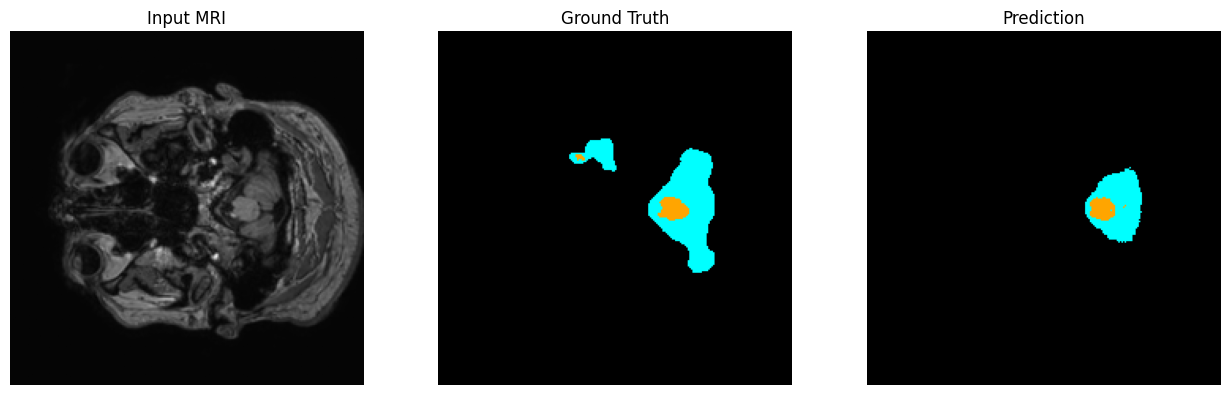

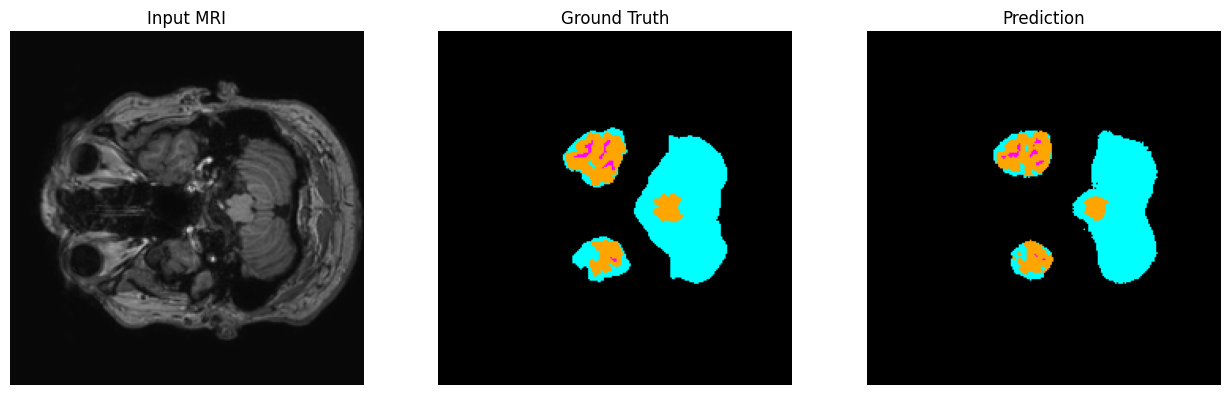

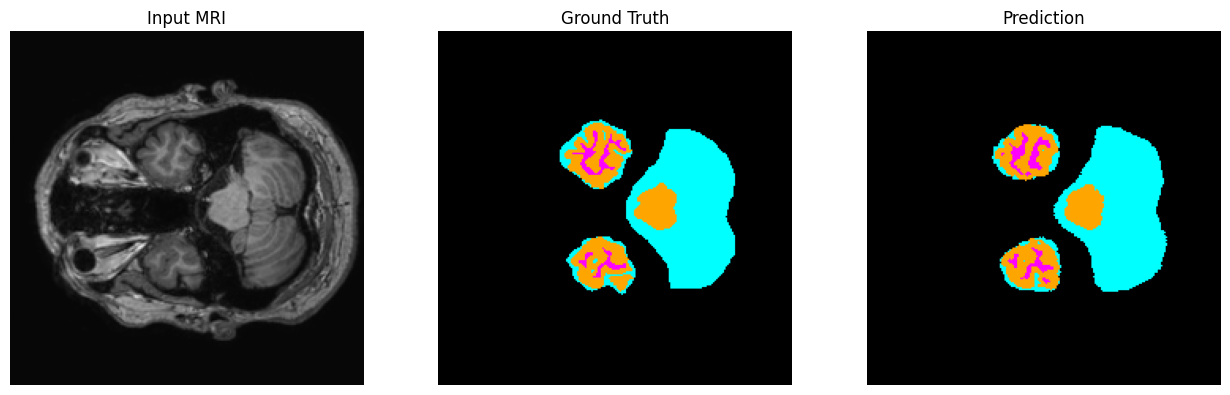

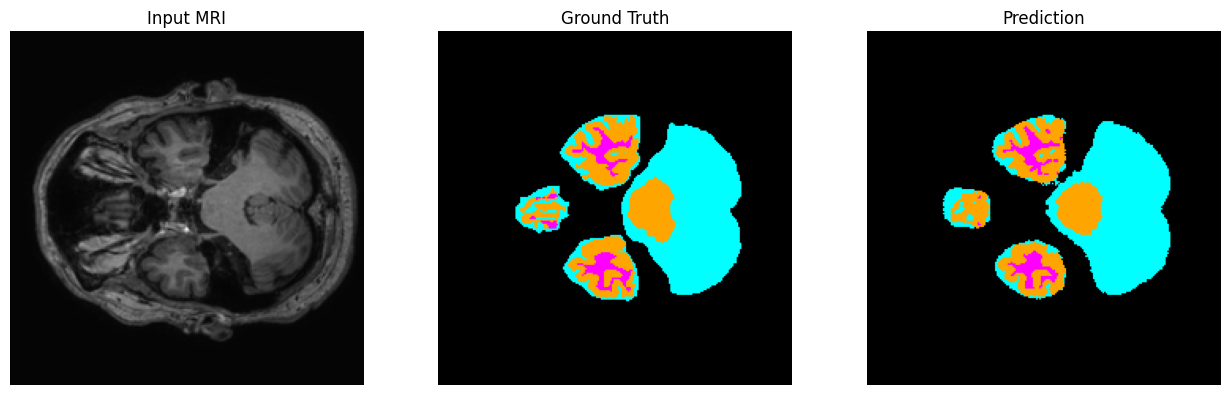

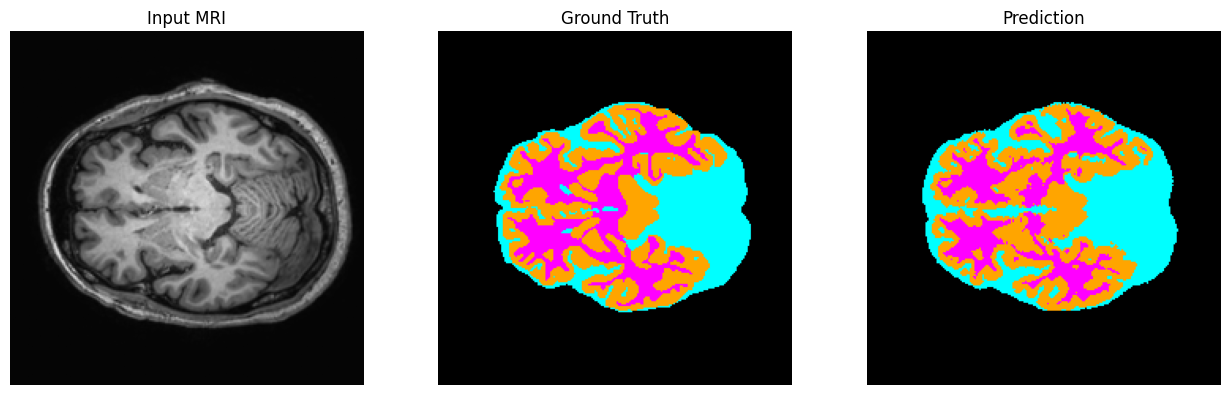

In [ ]:
show_predictions(test_dataset, num=5, model_to_use=best_model)

## 17. Save Final Model

In [ ]:
best_model.save('mrbrains_segnet_multiclass_final.keras')
print('Model saved ✓')

Model saved ✓
